# ASR Analysis (CS-Dialogue Test Baseline)

This notebook analyzes the canonical ASR baseline on the official test split:
- loads `asr_eval_cs_test_v1` artifacts
- reports headline quality/speed metrics
- breaks down results by language bucket, error mode, duration, and tag/composition slices
- analyzes conversation-level outliers and segment-level stability
- provides auto-generated summary points you can reuse in the report


## How To Interpret This Notebook

Before reading tables/plots, keep these rules in mind:
- Lower WER/CER is better (`0` is perfect). Values can exceed `1.0` when insertion errors are very high.
- WER is more sensitive to word/phrase-level mistakes; CER is more sensitive to character-level drift.
- RTF (`wall_time / audio_time`) is speed only. A low RTF does not imply high recognition quality.
- This project uses a fixed protocol (`asr_eval_v1`) with tag cleaning and mixed EN/ZH tokenization, so compare only runs scored with the same protocol.


In [1]:
from __future__ import annotations

import csv
import json
import math
import re
from collections import defaultdict
from pathlib import Path
from statistics import median

try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

ROOT = Path('..').resolve() if Path.cwd().name == 'notebooks' else Path('.').resolve()


def load_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8'))


def load_jsonl(path: Path):
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if line:
                rows.append(json.loads(line))
    return rows


def load_csv(path: Path):
    with path.open('r', encoding='utf-8', newline='') as f:
        return list(csv.DictReader(f))


def as_float(x, default=0.0):
    try:
        return float(x)
    except Exception:
        return default


def percentile(values, p):
    if not values:
        return None
    xs = sorted(values)
    k = (len(xs) - 1) * p
    lo = int(k)
    hi = min(lo + 1, len(xs) - 1)
    if lo == hi:
        return xs[lo]
    return xs[lo] + (xs[hi] - xs[lo]) * (k - lo)


def maybe_df(rows):
    if pd is not None:
        return pd.DataFrame(rows)
    return rows




def avg(vals):
    return sum(vals) / max(1, len(vals))

def resolve_workspace_path(raw_path):
    # Resolve Docker-style /workspace paths to local repo paths when needed.
    p = Path(str(raw_path or ''))
    if p.exists():
        return p
    s = str(p)
    if s.startswith('/workspace/'):
        local = ROOT / s.replace('/workspace/', '', 1)
        if local.exists():
            return local
    return p


## 1) Load Canonical Evaluation Run


In [2]:
EVAL_RUNS = {
    'test_baseline': ROOT / 'data/runs/asr_eval/asr_eval_cs_test_v1',
}

for name, p in EVAL_RUNS.items():
    print(f'{name:12} exists={p.exists()} path={p}')

run_data = {}
for name, p in EVAL_RUNS.items():
    run_data[name] = {
        'summary': load_json(p / 'summary.json'),
        'per_split': load_csv(p / 'per_split.csv'),
        'per_language': load_csv(p / 'per_language.csv'),
        'per_conversation': load_jsonl(p / 'per_conversation.jsonl'),
    }

print('Loaded runs:', list(run_data.keys()))
for k, v in run_data.items():
    print(f"{k}: splits={len(v['per_split'])}, conversations={len(v['per_conversation'])}")


test_baseline exists=True path=/home/shoo/personal/dlDev/school/AAI3008-multilingual-PII-masking/data/runs/asr_eval/asr_eval_cs_test_v1
Loaded runs: ['test_baseline']
test_baseline: splits=1, conversations=30


## 2) Run-Level Snapshot

This section is **table-first** (not chart-heavy) because it contains single-run headline facts:
- canonical `cs_test` WER/CER/RTF
- token/char volume
- throughput context

Result-breakdown views used in this notebook:
- Language-bucket breakdown (`en`, `zh`, `mixed`, `unknown`) from `per_language.csv`
- Conversation-level distribution and outlier tail behavior
- Duration/token-length/ratio sensitivity slices
- Transcript-tag and EN/ZH composition slices (`<FIL/>`, `<EN>`, `<CN>`, `<MIX>`)


In [3]:
rows = []
for run_name, d in run_data.items():
    for s in d['per_split']:
        rows.append({
            'run': run_name,
            'split': s['split'],
            'num_conversations': int(as_float(s['num_conversations'])),
            'wer': as_float(s['wer']),
            'cer': as_float(s['cer']),
            'rtf': as_float(s['rtf']),
            'segments_per_sec': as_float(s['segments_per_sec']),
            'audio_sec_per_wall_sec': as_float(s['audio_sec_per_wall_sec']),
            'segments': int(as_float(s['segments'])),
            'total_audio_sec': as_float(s['total_audio_sec']),
            'ref_word_tokens': int(as_float(s['ref_word_tokens'])),
            'ref_chars': int(as_float(s['ref_chars'])),
        })

maybe_df(rows)


[{'run': 'test_baseline',
  'split': 'cs_test',
  'num_conversations': 30,
  'wer': 0.3948743089953172,
  'cer': 0.5703181194294352,
  'rtf': 0.012421592020600808,
  'segments_per_sec': 10.648193506750525,
  'audio_sec_per_wall_sec': 80.50497861639091,
  'segments': 15213,
  'total_audio_sec': 115016.903,
  'ref_word_tokens': 177459,
  'ref_chars': 287785}]

In [4]:
aggregate_rows = []
for run_name, d in run_data.items():
    split_rows = [
        {
            'split': r['split'],
            'wer': as_float(r['wer']),
            'cer': as_float(r['cer']),
            'rtf': as_float(r['rtf']),
            'ref_word_tokens': max(1.0, as_float(r['ref_word_tokens'])),
            'ref_chars': max(1.0, as_float(r['ref_chars'])),
            'total_audio_sec': max(1.0, as_float(r['total_audio_sec'])),
            'num_conversations': int(as_float(r['num_conversations'])),
            'segments': int(as_float(r['segments'])),
        }
        for r in d['per_split']
    ]

    weighted_wer = sum(r['wer'] * r['ref_word_tokens'] for r in split_rows) / sum(r['ref_word_tokens'] for r in split_rows)
    weighted_cer = sum(r['cer'] * r['ref_chars'] for r in split_rows) / sum(r['ref_chars'] for r in split_rows)
    weighted_rtf = sum(r['rtf'] * r['total_audio_sec'] for r in split_rows) / sum(r['total_audio_sec'] for r in split_rows)

    aggregate_rows.append({
        'run': run_name,
        'num_splits': len(split_rows),
        'num_conversations': sum(r['num_conversations'] for r in split_rows),
        'weighted_wer': weighted_wer,
        'weighted_cer': weighted_cer,
        'weighted_rtf': weighted_rtf,
        'segments_total': sum(r['segments'] for r in split_rows),
        'audio_hours_total': sum(r['total_audio_sec'] for r in split_rows) / 3600.0,
    })

canonical_run = next(iter(run_data.keys()))
canonical_split = run_data[canonical_run]['per_split'][0]
canonical_wer = as_float(canonical_split['wer'])
canonical_cer = as_float(canonical_split['cer'])
canonical_rtf = as_float(canonical_split['rtf'])

maybe_df(aggregate_rows)


[{'run': 'test_baseline',
  'num_splits': 1,
  'num_conversations': 30,
  'weighted_wer': 0.3948743089953172,
  'weighted_cer': 0.5703181194294352,
  'weighted_rtf': 0.012421592020600808,
  'segments_total': 15213,
  'audio_hours_total': 31.949139722222224}]

### 2.1) Language-Bucket Breakdown

Interpretation:
- Compare bucket-level WER/CER only when multiple buckets have meaningful coverage share.
- Use `token_share_pct` / `char_share_pct` to avoid over-reading tiny buckets.

Current-run takeaway:
- This run is effectively single-bucket (`mixed` only), so there is no cross-bucket quality contrast yet.
- Treat this as a dataset-composition fact, not a model fairness conclusion.


In [5]:
lang_rows = []
for run_name, d in run_data.items():
    per_lang = d['per_language']

    # totals per run/split for share columns
    totals = {}
    for r in per_lang:
        key = (run_name, r['split'])
        totals.setdefault(key, {'ref_word_tokens': 0.0, 'ref_chars': 0.0})
        totals[key]['ref_word_tokens'] += as_float(r.get('ref_word_tokens'))
        totals[key]['ref_chars'] += as_float(r.get('ref_chars'))

    for r in per_lang:
        key = (run_name, r['split'])
        denom_tok = max(1.0, totals[key]['ref_word_tokens'])
        denom_chr = max(1.0, totals[key]['ref_chars'])
        tok = as_float(r.get('ref_word_tokens'))
        ch = as_float(r.get('ref_chars'))

        lang_rows.append({
            'run': run_name,
            'split': r['split'],
            'lang_bucket': r['lang_bucket'],
            'wer': as_float(r.get('wer')),
            'cer': as_float(r.get('cer')),
            'ref_word_tokens': int(tok),
            'ref_chars': int(ch),
            'token_share_pct': 100.0 * tok / denom_tok,
            'char_share_pct': 100.0 * ch / denom_chr,
        })

lang_rows = sorted(lang_rows, key=lambda x: (x['run'], x['split'], -x['ref_word_tokens'], x['lang_bucket']))
maybe_df(lang_rows)


[{'run': 'test_baseline',
  'split': 'cs_test',
  'lang_bucket': 'mixed',
  'wer': 0.3948743089953172,
  'cer': 0.5703181194294352,
  'ref_word_tokens': 177459,
  'ref_chars': 287785,
  'token_share_pct': 100.0,
  'char_share_pct': 100.0}]

In [6]:
if len(rows) <= 1:
    print('Single canonical run detected: keeping run-level snapshot table-only (no bar chart).')
elif plt is not None:
    plot_rows = rows
    labels = [f"{r['run']}:{r['split']}" for r in plot_rows]
    wers = [r['wer'] for r in plot_rows]
    cers = [r['cer'] for r in plot_rows]
    rtfs = [r['rtf'] for r in plot_rows]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].bar(labels, wers)
    axes[0].set_title('WER comparison')
    axes[0].tick_params(axis='x', rotation=45)

    axes[1].bar(labels, cers)
    axes[1].set_title('CER comparison')
    axes[1].tick_params(axis='x', rotation=45)

    axes[2].bar(labels, rtfs)
    axes[2].set_title('RTF comparison')
    axes[2].tick_params(axis='x', rotation=45)

    for ax in axes:
        ax.grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.show()
else:
    print('matplotlib not installed; skipping plots')


Single canonical run detected: keeping run-level snapshot table-only (no bar chart).


## Reader Notes: Quality vs Efficiency

Read this baseline along two primary axes:
- Quality axis: headline WER/CER, language-bucket WER/CER, conversation-tail behavior
- Efficiency axis: RTF and throughput (`audio_sec_per_wall_sec`, `segments_per_sec`)

A model can be operationally fast while still having unacceptable error-tail behavior.
Prioritize the tail/outlier analysis when deciding whether transcripts are safe for downstream PII detection and masking.


## 3) Test-Set Distribution and Outliers

This section is **chart-first** (histograms + ranked outliers) to expose tail risk that summary means hide.

How to read it:
- Median shows the typical conversation.
- P90 shows the error tail relevant for deployment risk.
- Bin counts show whether errors are concentrated in one regime or split into clusters.

Current-run takeaway:
- WER median is much lower than WER p90 (`~0.293` vs `~0.818`), indicating a heavy tail.
- Bin pattern is split: many conversations are decent (`<0.4`) while a notable group is severe (`0.6+`).


In [7]:
canonical_conv = run_data[canonical_run]['per_conversation']
full_conv = canonical_conv  # alias retained so downstream cells remain simple

full_wer_vals = [as_float(r['wer']) for r in full_conv if r.get('wer') is not None]
full_cer_vals = [as_float(r['cer']) for r in full_conv if r.get('cer') is not None]

dist_stats = {
    'num_conversations': len(full_conv),
    'wer_mean': sum(full_wer_vals) / len(full_wer_vals),
    'wer_median': median(full_wer_vals),
    'wer_p10': percentile(full_wer_vals, 0.10),
    'wer_p25': percentile(full_wer_vals, 0.25),
    'wer_p75': percentile(full_wer_vals, 0.75),
    'wer_p90': percentile(full_wer_vals, 0.90),
    'wer_min': min(full_wer_vals),
    'wer_max': max(full_wer_vals),
    'cer_mean': sum(full_cer_vals) / len(full_cer_vals),
    'cer_median': median(full_cer_vals),
    'cer_p90': percentile(full_cer_vals, 0.90),
    'cer_max': max(full_cer_vals),
}

maybe_df([dist_stats])


[{'num_conversations': 30,
  'wer_mean': 0.4457111393224998,
  'wer_median': 0.2926519922279905,
  'wer_p10': 0.18653752624774717,
  'wer_p25': 0.21537851845054704,
  'wer_p75': 0.7476650195416176,
  'wer_p90': 0.8176884806523458,
  'wer_min': 0.15185504745470232,
  'wer_max': 0.8710324089542265,
  'cer_mean': 0.6430469547097264,
  'cer_median': 0.4446791646203914,
  'cer_p90': 1.2214343002441523,
  'cer_max': 1.3508379888268156}]

In [8]:
def bucket_counts(values, edges):
    counts = [0 for _ in range(len(edges)-1)]
    for v in values:
        for i in range(len(edges)-1):
            lo, hi = edges[i], edges[i+1]
            if (v >= lo and v < hi) or (i == len(edges)-2 and v == hi):
                counts[i] += 1
                break
    return counts

wer_edges = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0]
counts = bucket_counts(full_wer_vals, wer_edges)
rows_hist = []
for i, c in enumerate(counts):
    rows_hist.append({'wer_bin': f"[{wer_edges[i]:.1f}, {wer_edges[i+1]:.1f}{')' if i < len(counts)-1 else ']'}", 'count': c})

maybe_df(rows_hist)


[{'wer_bin': '[0.0, 0.2)', 'count': 6},
 {'wer_bin': '[0.2, 0.4)', 'count': 12},
 {'wer_bin': '[0.4, 0.6)', 'count': 0},
 {'wer_bin': '[0.6, 0.8)', 'count': 8},
 {'wer_bin': '[0.8, 1.0)', 'count': 4},
 {'wer_bin': '[1.0, 2.0]', 'count': 0}]

Chart note:
- WER chart y-axis is **conversation count per WER bucket**.
- CER chart y-axis is **conversation count per CER bin**.


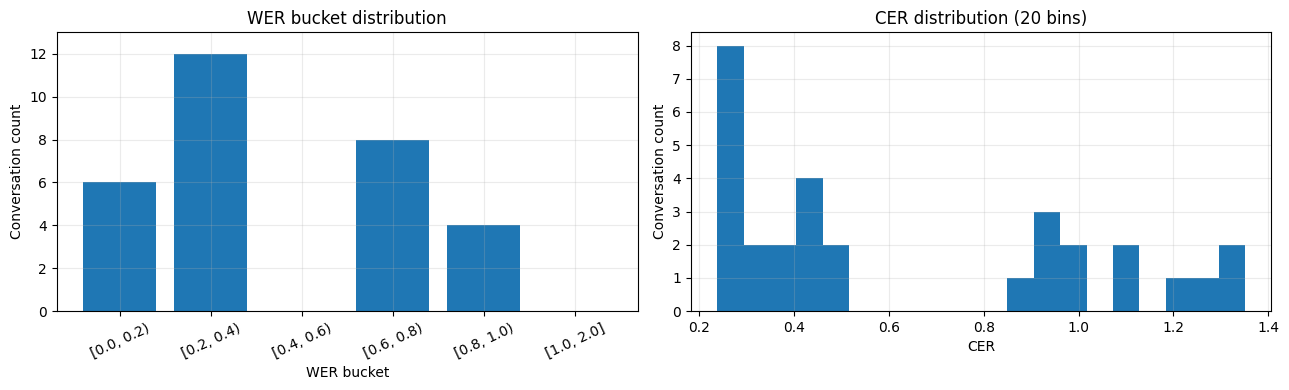

In [9]:
if plt is not None:
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    # WER: use the same coarse buckets as the table for interpretability.
    wer_labels = [r['wer_bin'] for r in rows_hist]
    wer_counts = [r['count'] for r in rows_hist]
    axes[0].bar(wer_labels, wer_counts)
    axes[0].set_title('WER bucket distribution')
    axes[0].set_xlabel('WER bucket')
    axes[0].set_ylabel('Conversation count')
    axes[0].tick_params(axis='x', rotation=25)
    axes[0].set_ylim(0, max(wer_counts) + 1 if wer_counts else 1)

    # CER: keep continuous histogram but make axis semantics explicit.
    axes[1].hist(full_cer_vals, bins=20)
    axes[1].set_title('CER distribution (20 bins)')
    axes[1].set_xlabel('CER')
    axes[1].set_ylabel('Conversation count')

    for ax in axes:
        ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
else:
    print('matplotlib not installed; skipping plots')


In [10]:
ranked_worst = sorted(full_conv, key=lambda r: as_float(r['wer']), reverse=True)
ranked_best = sorted(full_conv, key=lambda r: as_float(r['wer']))

print('Worst 10 by WER')
for r in ranked_worst[:10]:
    print(f"{r['item_id']} | WER={as_float(r['wer']):.4f} | CER={as_float(r['cer']):.4f} | dur={as_float(r.get('duration_sec')):.1f}s")

print('Best 10 by WER')
for r in ranked_best[:10]:
    print(f"{r['item_id']} | WER={as_float(r['wer']):.4f} | CER={as_float(r['cer']):.4f} | dur={as_float(r.get('duration_sec')):.1f}s")


Worst 10 by WER
test_00000000_ZH-CN_U1069_S0 | WER=0.8710 | CER=1.3508 | dur=2516.4s
test_00000026_ZH-CN_U1005_S0 | WER=0.8502 | CER=1.3345 | dur=5720.1s
test_00000013_ZH-CN_U1073_S0 | WER=0.8205 | CER=1.2164 | dur=2268.7s
test_00000010_ZH-CN_U1094_S0 | WER=0.8174 | CER=1.1056 | dur=2267.1s
test_00000022_ZH-CN_U1070_S0 | WER=0.7857 | CER=1.1174 | dur=2516.4s
test_00000025_ZH-CN_U1006_S0 | WER=0.7833 | CER=1.2669 | dur=5720.1s
test_00000003_ZH-CN_U1085_S0 | WER=0.7773 | CER=0.9496 | dur=2230.8s
test_00000001_ZH-CN_U1093_S0 | WER=0.7522 | CER=0.9522 | dur=2267.1s
test_00000014_ZH-CN_U1086_S0 | WER=0.7341 | CER=1.0020 | dur=2230.8s
test_00000015_ZH-CN_U1019_S0 | WER=0.6520 | CER=0.9294 | dur=3135.6s
Best 10 by WER
test_00000027_ZH-CN_U0031_S0 | WER=0.1519 | CER=0.2465 | dur=6066.9s
test_00000002_ZH-CN_U0044_S0 | WER=0.1640 | CER=0.2379 | dur=7220.2s
test_00000006_ZH-CN_U0033_S0 | WER=0.1865 | CER=0.2451 | dur=6244.1s
test_00000017_ZH-CN_U0074_S0 | WER=0.1865 | CER=0.2520 | dur=2134.1s
tes

## 4) Duration, Token-Length, and Ratio Effects

This section combines:
- **tables** for correlation/slice statistics
- **scatter charts** for relationship diagnostics

How to read it:
- Correlation magnitude indicates directional signal strength (not causality).
- Quartile slices help check whether relationships are stable or driven by a subset.

Current-run takeaway:
- `hyp/ref token ratio` is the strongest predictor of WER (large negative correlation in this run).
- Duration has weaker-to-moderate signal than token-ratio behavior.
- Practical implication: decoding/segmentation settings that avoid under-generation likely matter most.


In [11]:
def pearson(xs, ys):
    if not xs or len(xs) != len(ys):
        return None
    n = len(xs)
    mx = sum(xs) / n
    my = sum(ys) / n
    num = sum((x - mx) * (y - my) for x, y in zip(xs, ys))
    den_x = math.sqrt(sum((x - mx) ** 2 for x in xs))
    den_y = math.sqrt(sum((y - my) ** 2 for y in ys))
    if den_x == 0 or den_y == 0:
        return None
    return num / (den_x * den_y)

x_dur = [as_float(r.get('duration_sec')) for r in full_conv]
x_ref = [as_float(r.get('ref_word_tokens')) for r in full_conv]
x_ratio = [as_float(r.get('hyp_word_tokens')) / max(1.0, as_float(r.get('ref_word_tokens'))) for r in full_conv]
y_wer = [as_float(r.get('wer')) for r in full_conv]
y_cer = [as_float(r.get('cer')) for r in full_conv]

corr_rows = [
    {'feature': 'duration_sec', 'corr_with_wer': pearson(x_dur, y_wer), 'corr_with_cer': pearson(x_dur, y_cer)},
    {'feature': 'ref_word_tokens', 'corr_with_wer': pearson(x_ref, y_wer), 'corr_with_cer': pearson(x_ref, y_cer)},
    {'feature': 'hyp/ref_word_ratio', 'corr_with_wer': pearson(x_ratio, y_wer), 'corr_with_cer': pearson(x_ratio, y_cer)},
]

maybe_df(corr_rows)


[{'feature': 'duration_sec',
  'corr_with_wer': -0.3653308537023907,
  'corr_with_cer': -0.3204765913515947},
 {'feature': 'ref_word_tokens',
  'corr_with_wer': -0.3150417552785483,
  'corr_with_cer': -0.2804757466836624},
 {'feature': 'hyp/ref_word_ratio',
  'corr_with_wer': -0.9499175716440461,
  'corr_with_cer': -0.9190897095178802}]

In [12]:
# Duration quartiles vs WER
q1 = percentile(x_dur, 0.25)
q2 = percentile(x_dur, 0.50)
q3 = percentile(x_dur, 0.75)

buckets = [
    ('Q1_shortest', lambda d: d <= q1),
    ('Q2', lambda d: d > q1 and d <= q2),
    ('Q3', lambda d: d > q2 and d <= q3),
    ('Q4_longest', lambda d: d > q3),
]

rows_q = []
for name, fn in buckets:
    sub = [r for r in full_conv if fn(as_float(r.get('duration_sec')))]
    wers = [as_float(r['wer']) for r in sub]
    cers = [as_float(r['cer']) for r in sub]
    rows_q.append({
        'bucket': name,
        'count': len(sub),
        'avg_duration_min': (sum(as_float(r.get('duration_sec')) for r in sub) / max(1, len(sub))) / 60.0,
        'mean_wer': sum(wers) / max(1, len(wers)),
        'median_wer': median(wers) if wers else None,
        'mean_cer': sum(cers) / max(1, len(cers)),
    })

maybe_df(rows_q)


[{'bucket': 'Q1_shortest',
  'count': 8,
  'avg_duration_min': 35.68090286458334,
  'mean_wer': 0.3822148356070996,
  'median_wer': 0.2926519922279905,
  'mean_cer': 0.5376168253881808},
 {'bucket': 'Q2',
  'count': 7,
  'avg_duration_min': 39.380540625,
  'mean_wer': 0.6080171597140619,
  'median_wer': 0.7521757148777456,
  'mean_cer': 0.8402642312769631},
 {'bucket': 'Q3',
  'count': 7,
  'avg_duration_min': 71.40782083333333,
  'mean_wer': 0.6211260943573553,
  'median_wer': 0.6519687896933406,
  'mean_cer': 0.950181021156662},
 {'bucket': 'Q4_longest',
  'count': 8,
  'avg_duration_min': 106.99782877604166,
  'mean_wer': 0.21370158953978452,
  'median_wer': 0.20777075125228084,
  'mean_cer': 0.3071696588938711}]

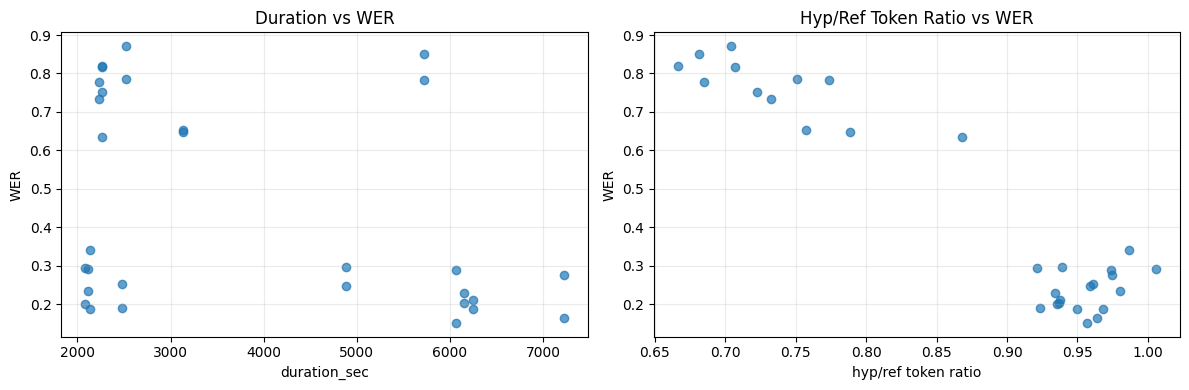

In [13]:
if plt is not None:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(x_dur, y_wer, alpha=0.7)
    axes[0].set_title('Duration vs WER')
    axes[0].set_xlabel('duration_sec')
    axes[0].set_ylabel('WER')
    axes[0].grid(alpha=0.25)

    axes[1].scatter(x_ratio, y_wer, alpha=0.7)
    axes[1].set_title('Hyp/Ref Token Ratio vs WER')
    axes[1].set_xlabel('hyp/ref token ratio')
    axes[1].set_ylabel('WER')
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


### 4.1) Error-Mode Breakdown (Under/Over-Generation)

How to read it:
- `under_generate` means the hypothesis is too short relative to reference.
- `balanced` means token volume is roughly aligned.
- Compare both quality (`mean WER/CER`) and prevalence (`share_pct`).

Current-run takeaway:
- Under-generation is the highest-error mode in this run (high mean WER/CER).
- It is also non-trivial in frequency, so this is a priority failure mode to address.


In [14]:
def ratio_mode(ratio):
    if ratio < 0.75:
        return 'under_generate_lt_0.75'
    if ratio <= 1.25:
        return 'balanced_0.75_to_1.25'
    return 'over_generate_gt_1.25'

error_mode_rows = []
for r in full_conv:
    ref_t = max(1.0, as_float(r.get('ref_word_tokens')))
    hyp_t = as_float(r.get('hyp_word_tokens'))
    ratio = hyp_t / ref_t
    error_mode_rows.append({
        'item_id': r['item_id'],
        'wer': as_float(r['wer']),
        'cer': as_float(r['cer']),
        'duration_sec': as_float(r.get('duration_sec')),
        'hyp_ref_ratio': ratio,
        'ratio_mode': ratio_mode(ratio),
    })

mode_summary = []
for mode in ['under_generate_lt_0.75', 'balanced_0.75_to_1.25', 'over_generate_gt_1.25']:
    sub = [x for x in error_mode_rows if x['ratio_mode'] == mode]
    if not sub:
        continue
    mode_summary.append({
        'ratio_mode': mode,
        'count': len(sub),
        'share_pct': 100.0 * len(sub) / max(1, len(error_mode_rows)),
        'mean_hyp_ref_ratio': avg([x['hyp_ref_ratio'] for x in sub]),
        'mean_wer': avg([x['wer'] for x in sub]),
        'mean_cer': avg([x['cer'] for x in sub]),
        'avg_duration_min': avg([x['duration_sec'] for x in sub]) / 60.0,
    })

maybe_df(mode_summary)


[{'ratio_mode': 'under_generate_lt_0.75',
  'count': 7,
  'share_pct': 23.333333333333332,
  'mean_hyp_ref_ratio': 0.6997584330447735,
  'mean_wer': 0.8032460533285873,
  'mean_cer': 1.1301709396203683,
  'avg_duration_min': 46.43100074404762},
 {'ratio_mode': 'balanced_0.75_to_1.25',
  'count': 23,
  'share_pct': 76.66666666666667,
  'mean_hyp_ref_ratio': 0.9192996351343851,
  'mean_wer': 0.33689616549456014,
  'mean_cer': 0.49479182886735706,
  'avg_duration_min': 69.21440774456522}]

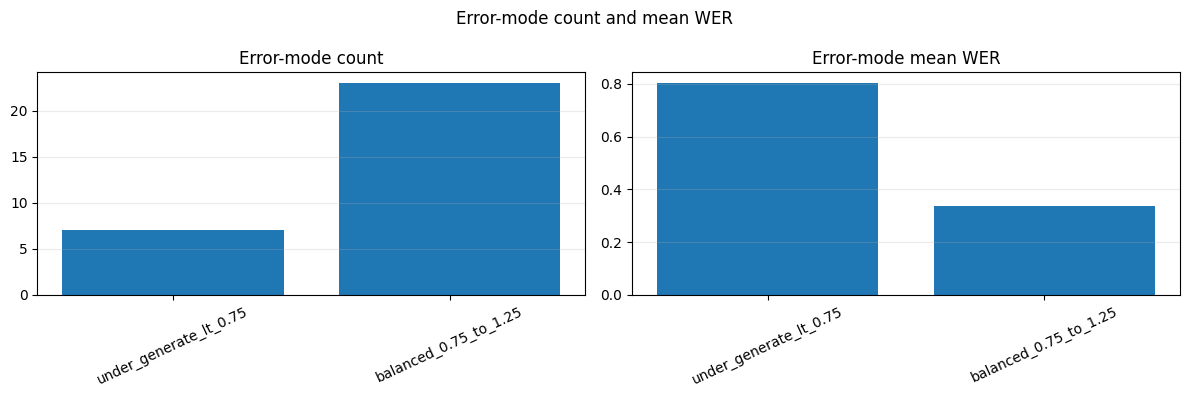

In [15]:
if plt is not None and mode_summary:
    labels = [r['ratio_mode'] for r in mode_summary]
    counts = [r['count'] for r in mode_summary]
    mean_wers = [r['mean_wer'] for r in mode_summary]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(labels, counts)
    axes[0].set_title('Error-mode count')
    axes[0].tick_params(axis='x', rotation=25)
    axes[0].grid(axis='y', alpha=0.25)

    axes[1].bar(labels, mean_wers)
    axes[1].set_title('Error-mode mean WER')
    axes[1].tick_params(axis='x', rotation=25)
    axes[1].grid(axis='y', alpha=0.25)

    plt.suptitle('Error-mode count and mean WER')
    plt.tight_layout()
    plt.show()


### 4.2) Segment-Level Stability Breakdown

How to read it:
- `segments_per_min` indicates segmentation density.
- `avg_segment_sec` and `seg_audio_coverage_ratio` indicate temporal fragmentation/coverage.
- Correlations with WER show whether segmentation metrics align with quality changes.

Current-run takeaway:
- Stability correlations are weak in this run (small absolute correlation values).
- Segmentation alone does not explain most quality variance compared with token-ratio effects.


In [16]:
asr_raw_for_stability = run_data[canonical_run]['summary']['splits'][0].get('asr_dir')
asr_dir_for_stability = resolve_workspace_path(asr_raw_for_stability)
segments_rows = load_jsonl(asr_dir_for_stability / 'segments.jsonl')

seg_by_item = defaultdict(list)
for s in segments_rows:
    seg_by_item[str(s.get('source_item_id'))].append(s)

stability_rows = []
for r in full_conv:
    item = r['item_id']
    segs = seg_by_item.get(item, [])
    seg_count = len(segs)
    seg_audio_sum = 0.0
    for s in segs:
        seg_audio_sum += max(0.0, as_float(s.get('end')) - as_float(s.get('start')))

    dur_sec = max(1.0, as_float(r.get('duration_sec')))
    stability_rows.append({
        'item_id': item,
        'wer': as_float(r['wer']),
        'cer': as_float(r['cer']),
        'duration_sec': dur_sec,
        'segments': seg_count,
        'segments_per_min': seg_count / (dur_sec / 60.0),
        'avg_segment_sec': seg_audio_sum / max(1, seg_count),
        'seg_audio_coverage_ratio': seg_audio_sum / dur_sec,
    })

stability_summary = {
    'mean_segments_per_min': avg([x['segments_per_min'] for x in stability_rows]),
    'p90_segments_per_min': percentile([x['segments_per_min'] for x in stability_rows], 0.90),
    'mean_avg_segment_sec': avg([x['avg_segment_sec'] for x in stability_rows]),
    'mean_seg_audio_coverage_ratio': avg([x['seg_audio_coverage_ratio'] for x in stability_rows]),
    'corr_segments_per_min_with_wer': pearson([x['segments_per_min'] for x in stability_rows], [x['wer'] for x in stability_rows]),
    'corr_avg_segment_sec_with_wer': pearson([x['avg_segment_sec'] for x in stability_rows], [x['wer'] for x in stability_rows]),
}

maybe_df([stability_summary])


[{'mean_segments_per_min': 7.685383847590271,
  'p90_segments_per_min': 9.897802825433514,
  'mean_avg_segment_sec': 4.756460277628026,
  'mean_seg_audio_coverage_ratio': 0.582234127955537,
  'corr_segments_per_min_with_wer': -0.15386899983659072,
  'corr_avg_segment_sec_with_wer': 0.11381120974156735}]

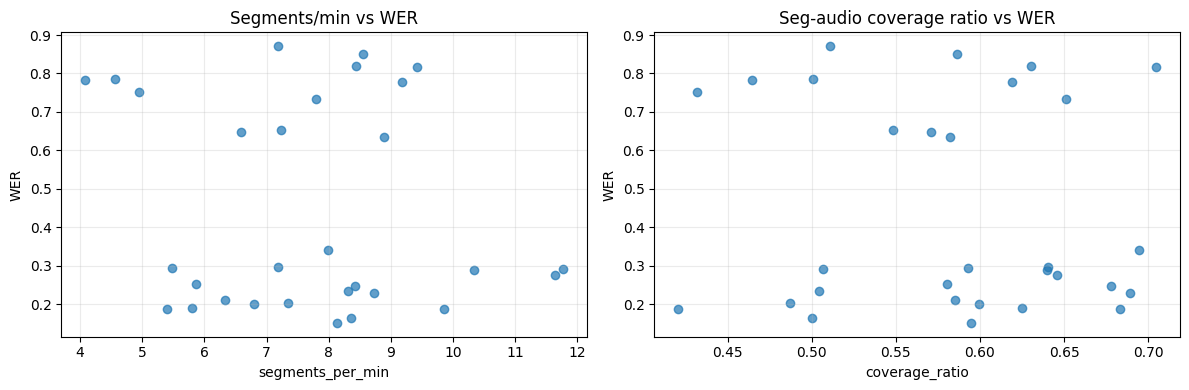

In [17]:
if plt is not None and stability_rows:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter([x['segments_per_min'] for x in stability_rows], [x['wer'] for x in stability_rows], alpha=0.7)
    axes[0].set_title('Segments/min vs WER')
    axes[0].set_xlabel('segments_per_min')
    axes[0].set_ylabel('WER')
    axes[0].grid(alpha=0.25)

    axes[1].scatter([x['seg_audio_coverage_ratio'] for x in stability_rows], [x['wer'] for x in stability_rows], alpha=0.7)
    axes[1].set_title('Seg-audio coverage ratio vs WER')
    axes[1].set_xlabel('coverage_ratio')
    axes[1].set_ylabel('WER')
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


## 5) Transcript-Tag Diagnostics (`<FIL/>`, `<EN>`, `<CN>`, `<MIX>`)

This section is mostly **table-based diagnostics** with one compact chart for top tag-error correlations.

How to read it:
- Tag-count correlations indicate association, not root cause.
- Use these as triage signals for where to inspect raw transcript behavior.

Current-run takeaway:
- Tag signals are informative but secondary compared with token-ratio effects.
- Use them to prioritize qualitative inspection slices, not as standalone causal claims.


In [18]:
manifest_raw = run_data[canonical_run]['summary']['splits'][0].get('manifest_path')
manifest_path = resolve_workspace_path(manifest_raw)
print('manifest_path:', manifest_path)

manifest_full = load_jsonl(manifest_path)
manifest_map = {str(r['item_id']): r for r in manifest_full}

TAG_PATTERNS = {
    'tag_FIL': re.compile(r'<FIL\s*/?>'),
    'tag_EN': re.compile(r'<EN>'),
    'tag_CN': re.compile(r'<CN>'),
    'tag_MIX': re.compile(r'<MIX>'),
    'tag_S': re.compile(r'<S>'),
    'tag_Z': re.compile(r'<Z>'),
}

TAG_RE_LOCAL = re.compile(r'<[^>]+>')
EN_CHAR_RE = re.compile(r'[A-Za-z]')
ZH_CHAR_RE = re.compile(r'[\u4e00-\u9fff]')

tag_rows = []
for r in full_conv:
    item_id = r['item_id']
    tr_raw = str(manifest_map.get(item_id, {}).get('transcript') or '')
    tr_clean = ' '.join(TAG_RE_LOCAL.sub(' ', tr_raw).split())

    en_chars = len(EN_CHAR_RE.findall(tr_clean))
    zh_chars = len(ZH_CHAR_RE.findall(tr_clean))
    total_lang_chars = max(1, en_chars + zh_chars)

    row = {
        'item_id': item_id,
        'wer': as_float(r['wer']),
        'cer': as_float(r['cer']),
        'duration_sec': as_float(r.get('duration_sec')),
        'ref_word_tokens': as_float(r.get('ref_word_tokens')),
        'en_chars': en_chars,
        'zh_chars': zh_chars,
        'en_char_share': en_chars / total_lang_chars,
        'zh_char_share': zh_chars / total_lang_chars,
    }
    for k, pat in TAG_PATTERNS.items():
        row[k] = len(pat.findall(tr_raw))
    tag_rows.append(row)

maybe_df(tag_rows[:5])


manifest_path: /home/shoo/personal/dlDev/school/AAI3008-multilingual-PII-masking/data/raw/cs_dialogue/cs_test/long_wav/manifest.jsonl


[{'item_id': 'test_00000000_ZH-CN_U1069_S0',
  'wer': 0.8710324089542265,
  'cer': 1.3508379888268156,
  'duration_sec': 2516.40275,
  'ref_word_tokens': 2993.0,
  'en_chars': 1974,
  'zh_chars': 2501,
  'en_char_share': 0.4411173184357542,
  'zh_char_share': 0.5588826815642458,
  'tag_FIL': 61,
  'tag_EN': 74,
  'tag_CN': 136,
  'tag_MIX': 19,
  'tag_S': 426,
  'tag_Z': 60},
 {'item_id': 'test_00000001_ZH-CN_U1093_S0',
  'wer': 0.7521757148777456,
  'cer': 0.9522128060263654,
  'duration_sec': 2267.1175,
  'ref_word_tokens': 2413.0,
  'en_chars': 2522,
  'zh_chars': 1726,
  'en_char_share': 0.5936911487758946,
  'zh_char_share': 0.4063088512241055,
  'tag_FIL': 73,
  'tag_EN': 28,
  'tag_CN': 83,
  'tag_MIX': 17,
  'tag_S': 230,
  'tag_Z': 38},
 {'item_id': 'test_00000002_ZH-CN_U0044_S0',
  'wer': 0.16396761133603238,
  'cer': 0.237934430842831,
  'duration_sec': 7220.2174375,
  'ref_word_tokens': 9880.0,
  'en_chars': 5748,
  'zh_chars': 8466,
  'en_char_share': 0.4043900379907134,
 

In [19]:
# Correlation of tag frequencies with WER/CER
corr_tag_rows = []
for k in TAG_PATTERNS.keys():
    xs = [as_float(r[k]) for r in tag_rows]
    ys_w = [as_float(r['wer']) for r in tag_rows]
    ys_c = [as_float(r['cer']) for r in tag_rows]
    corr_tag_rows.append({
        'tag_feature': k,
        'corr_with_wer': pearson(xs, ys_w),
        'corr_with_cer': pearson(xs, ys_c),
        'mean_count': sum(xs) / max(1, len(xs)),
        'max_count': max(xs) if xs else 0,
    })

corr_tag_rows = sorted(corr_tag_rows, key=lambda r: abs(as_float(r['corr_with_wer'])), reverse=True)
maybe_df(corr_tag_rows)


[{'tag_feature': 'tag_FIL',
  'corr_with_wer': -0.3395662108319748,
  'corr_with_cer': -0.3286444822569099,
  'mean_count': 102.4,
  'max_count': 279.0},
 {'tag_feature': 'tag_MIX',
  'corr_with_wer': -0.31328762179802894,
  'corr_with_cer': -0.31702480672346534,
  'mean_count': 34.266666666666666,
  'max_count': 89.0},
 {'tag_feature': 'tag_EN',
  'corr_with_wer': 0.10862406849165217,
  'corr_with_cer': 0.1523476374472851,
  'mean_count': 61.36666666666667,
  'max_count': 150.0},
 {'tag_feature': 'tag_Z',
  'corr_with_wer': -0.06557616267948448,
  'corr_with_cer': -0.07795736073068006,
  'mean_count': 54.53333333333333,
  'max_count': 222.0},
 {'tag_feature': 'tag_S',
  'corr_with_wer': 0.04438445264998978,
  'corr_with_cer': 0.0724295621788568,
  'mean_count': 362.2,
  'max_count': 1066.0},
 {'tag_feature': 'tag_CN',
  'corr_with_wer': -0.03608080875115102,
  'corr_with_cer': -0.021528905346581965,
  'mean_count': 112.96666666666667,
  'max_count': 373.0}]

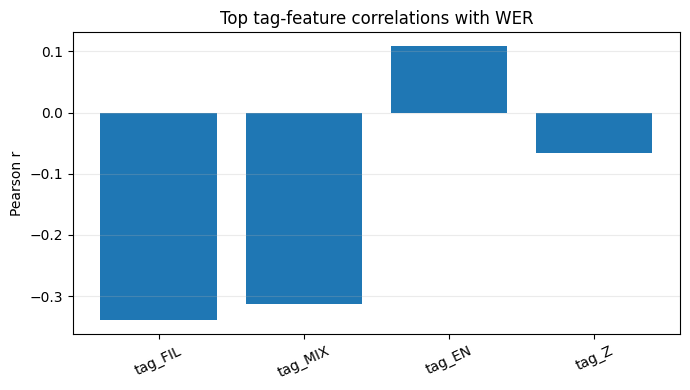

In [20]:
if plt is not None and corr_tag_rows:
    top = corr_tag_rows[:4]
    labels = [r['tag_feature'] for r in top]
    vals = [r['corr_with_wer'] for r in top]

    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.bar(labels, vals)
    ax.set_title('Top tag-feature correlations with WER')
    ax.set_ylabel('Pearson r')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


In [21]:
# High-FIL slice (top quartile by FIL count)
fil_counts = [as_float(r['tag_FIL']) for r in tag_rows]
fil_q3 = percentile(fil_counts, 0.75)

high_fil = [r for r in tag_rows if as_float(r['tag_FIL']) >= fil_q3]
low_fil = [r for r in tag_rows if as_float(r['tag_FIL']) < fil_q3]

slice_rows = [
    {
        'slice': 'high_FIL_top_quartile',
        'count': len(high_fil),
        'mean_wer': sum(as_float(r['wer']) for r in high_fil) / max(1, len(high_fil)),
        'mean_cer': sum(as_float(r['cer']) for r in high_fil) / max(1, len(high_fil)),
    },
    {
        'slice': 'low_FIL_bottom_3_quartiles',
        'count': len(low_fil),
        'mean_wer': sum(as_float(r['wer']) for r in low_fil) / max(1, len(low_fil)),
        'mean_cer': sum(as_float(r['cer']) for r in low_fil) / max(1, len(low_fil)),
    },
]

maybe_df(slice_rows)


[{'slice': 'high_FIL_top_quartile',
  'count': 8,
  'mean_wer': 0.35416755834398994,
  'mean_cer': 0.5254912459292137},
 {'slice': 'low_FIL_bottom_3_quartiles',
  'count': 22,
  'mean_wer': 0.47899971422377613,
  'mean_cer': 0.6857944851753675}]

### 5.1) Mixed-Composition Breakdown (EN-Char Share Quartiles)

How to read it:
- Quartiles test whether error monotonically increases with EN-share or ZH-share.
- If non-monotonic, interaction effects likely dominate simple language-ratio explanations.

Current-run takeaway:
- Difficulty is non-monotonic across EN-share quartiles in this run.
- Conclusion: "more EN" is not automatically harder/easier; mixed composition interacts with other factors.


In [22]:
en_shares = [as_float(r['en_char_share']) for r in tag_rows]
q1_en = percentile(en_shares, 0.25)
q2_en = percentile(en_shares, 0.50)
q3_en = percentile(en_shares, 0.75)

mix_buckets = [
    ('Q1_lowest_EN_share', lambda x: x <= q1_en),
    ('Q2', lambda x: x > q1_en and x <= q2_en),
    ('Q3', lambda x: x > q2_en and x <= q3_en),
    ('Q4_highest_EN_share', lambda x: x > q3_en),
]

mix_rows = []
for name, fn in mix_buckets:
    sub = [r for r in tag_rows if fn(as_float(r['en_char_share']))]
    if not sub:
        continue
    mix_rows.append({
        'en_share_bucket': name,
        'count': len(sub),
        'mean_en_share': avg([as_float(r['en_char_share']) for r in sub]),
        'mean_wer': avg([as_float(r['wer']) for r in sub]),
        'median_wer': median([as_float(r['wer']) for r in sub]),
        'mean_cer': avg([as_float(r['cer']) for r in sub]),
        'mean_tag_FIL': avg([as_float(r['tag_FIL']) for r in sub]),
    })

maybe_df(mix_rows)


[{'en_share_bucket': 'Q1_lowest_EN_share',
  'count': 8,
  'mean_en_share': 0.4270931768839708,
  'mean_wer': 0.48775621829117916,
  'median_wer': 0.4289955716586151,
  'mean_cer': 0.7308078676035131,
  'mean_tag_FIL': 117.25},
 {'en_share_bucket': 'Q2',
  'count': 7,
  'mean_en_share': 0.5079789757427334,
  'mean_wer': 0.5200545230585931,
  'median_wer': 0.6519687896933406,
  'mean_cer': 0.7506333077760141,
  'mean_tag_FIL': 87.14285714285714},
 {'en_share_bucket': 'Q3',
  'count': 7,
  'mean_en_share': 0.5350054668208418,
  'mean_wer': 0.31547632082381,
  'median_wer': 0.2471864406779661,
  'mean_cer': 0.45616688513214326,
  'mean_tag_FIL': 111.28571428571429},
 {'en_share_bucket': 'Q4_highest_EN_share',
  'count': 8,
  'mean_en_share': 0.6065223702408242,
  'mean_wer': 0.45257106577109235,
  'median_wer': 0.31770455492333194,
  'mean_cer': 0.6246680437633232,
  'mean_tag_FIL': 93.125}]

### 5.2) Segment-Language Diagnostics (Hypothesis-Side, Diagnostic Only)

How to read it:
- This uses ASR `segments.jsonl` language tags (`en`/`zh`/`mixed`/`unknown`) as a **secondary diagnostic**, not official scoring.
- Because segment language tags come from hypothesis text, treat associations with WER as triage signals, not causal proof.
- Use this view to identify whether language-composition patterns in decoded output align with harder/easier conversations.

Current-run takeaway:
- Segment-language composition shows stronger contrast than conversation-level `lang_bucket` in this run.
- EN-dominant-segment conversations appear harder than ZH-dominant-segment conversations here (diagnostic signal only).


In [23]:
asr_raw_for_seg_lang = run_data[canonical_run]['summary']['splits'][0].get('asr_dir')
asr_dir_for_seg_lang = resolve_workspace_path(asr_raw_for_seg_lang)
segments_rows_seg_lang = load_jsonl(asr_dir_for_seg_lang / 'segments.jsonl')

seg_lang_by_item = defaultdict(lambda: {'total': 0, 'en': 0, 'zh': 0, 'mixed': 0, 'unknown': 0})
for s in segments_rows_seg_lang:
    item_id = str(s.get('source_item_id'))
    lang = str(s.get('language') or 'unknown').lower()
    if lang not in {'en', 'zh', 'mixed', 'unknown'}:
        lang = 'unknown'
    seg_lang_by_item[item_id]['total'] += 1
    seg_lang_by_item[item_id][lang] += 1

seg_lang_rows = []
for r in full_conv:
    item_id = str(r['item_id'])
    c = seg_lang_by_item.get(item_id, {'total': 0, 'en': 0, 'zh': 0, 'mixed': 0, 'unknown': 0})
    total = max(1, int(c['total']))
    dominant = max(['en', 'zh', 'mixed', 'unknown'], key=lambda k: c[k])
    seg_lang_rows.append({
        'item_id': item_id,
        'wer': as_float(r.get('wer')),
        'cer': as_float(r.get('cer')),
        'duration_sec': as_float(r.get('duration_sec')),
        'segment_count': int(c['total']),
        'dominant_seg_lang': dominant,
        'en_seg_share': c['en'] / total,
        'zh_seg_share': c['zh'] / total,
        'mixed_seg_share': c['mixed'] / total,
        'unknown_seg_share': c['unknown'] / total,
    })

dominant_seg_summary = []
for lang in ['en', 'zh', 'mixed', 'unknown']:
    sub = [x for x in seg_lang_rows if x['dominant_seg_lang'] == lang]
    if not sub:
        continue
    dominant_seg_summary.append({
        'dominant_seg_lang': lang,
        'count': len(sub),
        'share_pct': 100.0 * len(sub) / max(1, len(seg_lang_rows)),
        'mean_wer': avg([x['wer'] for x in sub]),
        'mean_cer': avg([x['cer'] for x in sub]),
        'avg_duration_min': avg([x['duration_sec'] for x in sub]) / 60.0,
    })

en_seg_shares = [x['en_seg_share'] for x in seg_lang_rows]
q1_seg_en = percentile(en_seg_shares, 0.25)
q2_seg_en = percentile(en_seg_shares, 0.50)
q3_seg_en = percentile(en_seg_shares, 0.75)

def seg_en_bucket(v):
    if v <= q1_seg_en:
        return 'Q1_lowest_EN_seg_share'
    if v <= q2_seg_en:
        return 'Q2'
    if v <= q3_seg_en:
        return 'Q3'
    return 'Q4_highest_EN_seg_share'

for x in seg_lang_rows:
    x['en_seg_share_bucket'] = seg_en_bucket(x['en_seg_share'])

seg_en_share_summary = []
for b in ['Q1_lowest_EN_seg_share', 'Q2', 'Q3', 'Q4_highest_EN_seg_share']:
    sub = [x for x in seg_lang_rows if x['en_seg_share_bucket'] == b]
    if not sub:
        continue
    seg_en_share_summary.append({
        'en_seg_share_bucket': b,
        'count': len(sub),
        'share_pct': 100.0 * len(sub) / max(1, len(seg_lang_rows)),
        'mean_wer': avg([x['wer'] for x in sub]),
        'mean_cer': avg([x['cer'] for x in sub]),
        'min_en_seg_share': min(x['en_seg_share'] for x in sub),
        'max_en_seg_share': max(x['en_seg_share'] for x in sub),
    })

maybe_df(dominant_seg_summary), maybe_df(seg_en_share_summary)


([{'dominant_seg_lang': 'en',
   'count': 12,
   'share_pct': 40.0,
   'mean_wer': 0.7605640515020061,
   'mean_cer': 1.091184707302234,
   'avg_duration_min': 50.385259895833336},
  {'dominant_seg_lang': 'zh',
   'count': 18,
   'share_pct': 60.0,
   'mean_wer': 0.2358091978694956,
   'mean_cer': 0.3442884529813879,
   'avg_duration_min': 72.9069591435185}],
 [{'en_seg_share_bucket': 'Q1_lowest_EN_seg_share',
   'count': 8,
   'share_pct': 26.666666666666668,
   'mean_wer': 0.26571103364438176,
   'mean_cer': 0.4046495005287849,
   'min_en_seg_share': 0.03855421686746988,
   'max_en_seg_share': 0.09154929577464789},
  {'en_seg_share_bucket': 'Q2',
   'count': 7,
   'share_pct': 23.333333333333332,
   'mean_wer': 0.2202330620657711,
   'mean_cer': 0.30945877022299995,
   'min_en_seg_share': 0.09197080291970802,
   'max_en_seg_share': 0.12357142857142857},
  {'en_seg_share_bucket': 'Q3',
   'count': 7,
   'share_pct': 23.333333333333332,
   'mean_wer': 0.46377532750154676,
   'mean_cer'

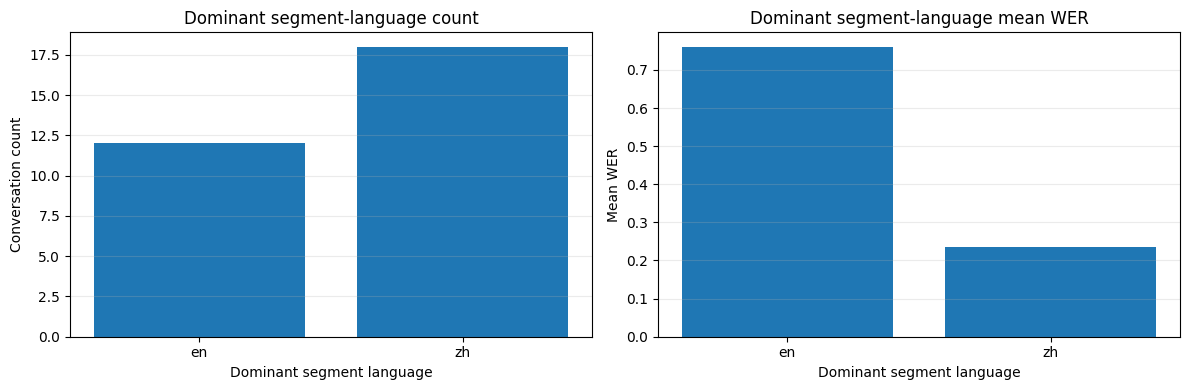

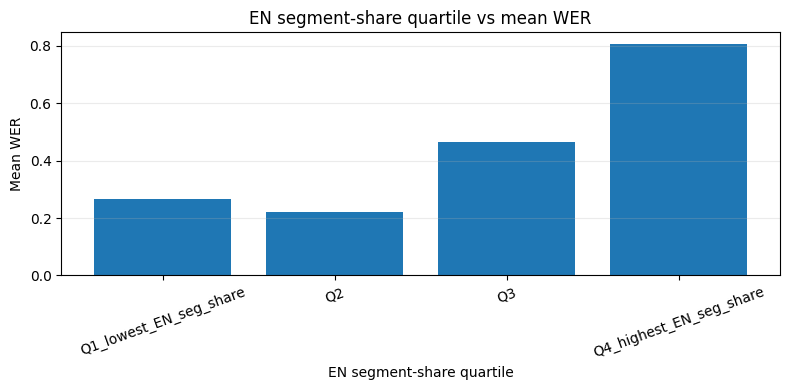

In [24]:
if plt is not None and dominant_seg_summary:
    labels = [r['dominant_seg_lang'] for r in dominant_seg_summary]
    counts = [r['count'] for r in dominant_seg_summary]
    mean_wers = [r['mean_wer'] for r in dominant_seg_summary]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].bar(labels, counts)
    axes[0].set_title('Dominant segment-language count')
    axes[0].set_xlabel('Dominant segment language')
    axes[0].set_ylabel('Conversation count')
    axes[0].grid(axis='y', alpha=0.25)

    axes[1].bar(labels, mean_wers)
    axes[1].set_title('Dominant segment-language mean WER')
    axes[1].set_xlabel('Dominant segment language')
    axes[1].set_ylabel('Mean WER')
    axes[1].grid(axis='y', alpha=0.25)

    plt.tight_layout()
    plt.show()

if plt is not None and seg_en_share_summary:
    labels = [r['en_seg_share_bucket'] for r in seg_en_share_summary]
    vals = [r['mean_wer'] for r in seg_en_share_summary]

    fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    ax.bar(labels, vals)
    ax.set_title('EN segment-share quartile vs mean WER')
    ax.set_xlabel('EN segment-share quartile')
    ax.set_ylabel('Mean WER')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()


## 6) Outlier Drill-Down (Reference vs Hypothesis)


In [25]:
def aggregate_hyp_by_item(segments_path: Path):
    by_item = defaultdict(list)
    for seg in load_jsonl(segments_path):
        by_item[str(seg.get('source_item_id'))].append(seg)
    out = {}
    for item_id, rows in by_item.items():
        rows = sorted(rows, key=lambda r: (as_float(r.get('start')), str(r.get('segment_id') or '')))
        out[item_id] = ' '.join((r.get('text') or '').strip() for r in rows if (r.get('text') or '').strip())
    return out

TAG_RE = re.compile(r'<[^>]+>')
def clean_text(x):
    return ' '.join(TAG_RE.sub(' ', str(x or '')).split())

asr_raw = run_data[canonical_run]['summary']['splits'][0].get('asr_dir')
asr_dir = resolve_workspace_path(asr_raw)
print('asr_dir:', asr_dir)

hyp_map = aggregate_hyp_by_item(asr_dir / 'segments.jsonl')

for r in ranked_worst[:3]:
    item_id = r['item_id']
    ref = clean_text(manifest_map.get(item_id, {}).get('transcript', ''))
    hyp = clean_text(hyp_map.get(item_id, ''))
    print('=' * 90)
    print(f"item={item_id} | WER={as_float(r['wer']):.4f} | CER={as_float(r['cer']):.4f}")
    print('REF[:700]:', ref[:700])
    print('HYP[:700]:', hyp[:700])
    print('LEN(ref_chars)=', len(ref), 'LEN(hyp_chars)=', len(hyp))


asr_dir: /home/shoo/personal/dlDev/school/AAI3008-multilingual-PII-masking/data/runs/asr/asr_baseline_cs_test
item=test_00000000_ZH-CN_U1069_S0 | WER=0.8710 | CER=1.3508
REF[:700]: Hello, my name is Bob. I'm twenty five. From Chengdu, Sichuan province . I have just graduated and are currently interesting in Chengdu. What's your? What's your name? I like I like play games and travel, and I go to many cities in China. And do you what's your favorite city? Yes. I have many friends and I all also enjoy traveling with them during pace time. And do you like traveling and . Play games with me ? What's your job? What are you doing? In Chengdu? Yeah. What city have you been to? Do you like Chengdu? There are many pandas. And I like pandas. Panda has panda are very cute. I like her black eyes and white fur. So. Are you like animals? Cute animals? Oh, that's in interesting . What
HYP[:700]: Hello, my name is Bob, I'm 25, from Chengdu, Sichuan province. I have just graduated and I'm currently inte

### 6.1) Decent-Quality Conversation Examples

In addition to worst-case outliers, this subsection shows representative "decent" conversations.
Default target band is `0.00 <= WER <= 0.20`; if too few items exist, it falls back to samples closest to median WER.

How to use these examples:
- Compare REF/HYP to identify what *works well* (not just what fails).
- Use `hyp/ref_tok_ratio` and duration context to contrast with outlier examples.


In [26]:
decent_low, decent_high = 0.00, 0.20
mid_target = (decent_low + decent_high) / 2.0

pool = [r for r in full_conv if decent_low <= as_float(r.get('wer')) <= decent_high]
selection_mode = 'band_0.00_to_0.20'

if len(pool) < 3:
    med = as_float(dist_stats.get('wer_median'))
    pool = sorted(full_conv, key=lambda r: abs(as_float(r.get('wer')) - med))
    selection_mode = 'fallback_near_median'
else:
    pool = sorted(pool, key=lambda r: abs(as_float(r.get('wer')) - mid_target))

print('Decent example selection mode:', selection_mode)

for r in pool[:3]:
    item_id = r['item_id']
    ref = clean_text(manifest_map.get(item_id, {}).get('transcript', ''))
    hyp = clean_text(hyp_map.get(item_id, ''))
    ratio = as_float(r.get('hyp_word_tokens')) / max(1.0, as_float(r.get('ref_word_tokens')))

    print('=' * 90)
    print(
        f"item={item_id} | WER={as_float(r.get('wer')):.4f} | "
        f"CER={as_float(r.get('cer')):.4f} | dur_min={as_float(r.get('duration_sec'))/60.0:.1f} | "
        f"hyp/ref_tok_ratio={ratio:.2f}"
    )
    print('REF[500]:', ref[:500])
    print('HYP[500]:', hyp[:500])


Decent example selection mode: band_0.00_to_0.20
item=test_00000027_ZH-CN_U0031_S0 | WER=0.1519 | CER=0.2465 | dur_min=101.1 | hyp/ref_tok_ratio=0.96
REF[500]: 你好，我叫**，可以叫我丸子，请多多指教 ，你是哪里人呀？ 哦，我我出生在香港，但是后来就去了澳门，现在也在北京读书。 我现在就读于中国人民大学，你呢？ 哦，那我们学校还挺近的，我是读的俄语专业，所以我们也算就是有点缘分，我是外国语学院的。 其实也还好，主要是一些基础，比如说会需要背单词，就是比较大量的单词这样子。 我，嗯哼。 我觉得让我最头疼的就是专业课了。因为像你说的，其实学语言它本身就是一个很枯燥的东西。但是我们就是在枯燥的东西里面找到一些我们感兴趣的东西，才可以一直坚持学下去。我在专业课之外，我还学了一些呃选修了一些新闻，还有法学院的课。这些就是有点像在中学时期的一些美术课，就是因为兴趣所以想学，所以我在后面研究生也可能想要往这些方向发展。你对自己的未来有什么想法吗？就是包括研究生啊，或者是还是想要直接工作呢？ 哦，刚刚说到交换的东西真的是太巧了。我刚好也在上一个学期的时候去了俄罗斯留学。因为提到我是俄语的学生嘛，然后当时也是感觉文化上有非常大的差异。我在平常的话我会看书，还有听一下音乐，但是比如说最长的还是看小说呀，还有看一下漫画之类的这些一个人的 一个人的兴趣，可以让我更好
HYP[500]: 你好,我叫婉盈,可以叫我婉子 请多多指教 你是哪里人呀? 我出生在香港的时候后来就去了澳门 现在也在北京读书 我现在就读于中国人民大学 你呢? 哦,那我们学校还挺近的 我是读的俄语专业 所以我们也算就是有点缘分 我是外国语学院的 其实也还好,主要是一些技术,比如说会需要备单词,就是比较大量的单词,这样子。 我觉得让我最头疼的就是专业课了,因为像你说的其实学语言,它本身就是一个很枯燥的东西, 但是我们就是在枯燥的东西里面找到一些我们感兴趣的东西才可以一直坚持学下去。 我在专业课之外,我还选修了一些新闻还有法学院的课 这些就是有点像在中学时期的一些美术课 就是因为兴趣所以想学 所以我在后面研究生也可能想要往这些方向发展 你对自己的未来有什么想法吗? 就是

## 7) Error Slices for Reporting

How to read it:
- `share_pct` tells you deployment impact of each quality band.
- `mean_wer/cor` in each slice tells you severity.
- `avg_duration_min` helps check whether long/short conversations dominate a slice.

Current-run takeaway:
- A meaningful fraction of conversations are in good/decent ranges, but severe slices still contribute substantial tail risk.
- Report both central tendency and tail share together.


In [27]:
slices = {
    'very_good_wer_le_0_20': [r for r in full_conv if as_float(r['wer']) <= 0.20],
    'good_0_20_to_0_40': [r for r in full_conv if 0.20 < as_float(r['wer']) <= 0.40],
    'moderate_0_40_to_0_80': [r for r in full_conv if 0.40 < as_float(r['wer']) <= 0.80],
    'severe_wer_gt_0_80': [r for r in full_conv if as_float(r['wer']) > 0.80],
    'cer_gt_1_0': [r for r in full_conv if as_float(r['cer']) > 1.0],
}

slice_report = []
for name, sub in slices.items():
    slice_report.append({
        'slice': name,
        'count': len(sub),
        'share_pct': 100.0 * len(sub) / max(1, len(full_conv)),
        'mean_wer': avg([as_float(r['wer']) for r in sub]) if sub else None,
        'mean_cer': avg([as_float(r['cer']) for r in sub]) if sub else None,
        'avg_duration_min': avg([as_float(r.get('duration_sec')) for r in sub]) / 60.0 if sub else None,
    })

maybe_df(slice_report)


[{'slice': 'very_good_wer_le_0_20',
  'count': 6,
  'share_pct': 20.0,
  'mean_wer': 0.17992865561378268,
  'mean_cer': 0.25388275471896504,
  'avg_duration_min': 72.8457265625},
 {'slice': 'good_0_20_to_0_40',
  'count': 12,
  'share_pct': 40.0,
  'mean_wer': 0.2637494689973521,
  'mean_cer': 0.38949130211259936,
  'avg_duration_min': 72.93757543402778},
 {'slice': 'moderate_0_40_to_0_80',
  'count': 8,
  'share_pct': 26.666666666666668,
  'mean_wer': 0.7209568467075785,
  'mean_cer': 1.0108592512360532,
  'avg_duration_min': 48.96887643229166},
 {'slice': 'severe_wer_gt_0_80',
  'count': 4,
  'share_pct': 13.333333333333334,
  'mean_wer': 0.8397784610908613,
  'mean_cer': 1.2518356194345956,
  'avg_duration_min': 53.21802682291666},
 {'slice': 'cer_gt_1_0',
  'count': 7,
  'share_pct': 23.333333333333332,
  'mean_wer': 0.8088920745255024,
  'mean_cer': 1.1990971762392768,
  'avg_duration_min': 55.33253705357142}]

## 8) Auto-Generated Summary Text

This block is intended as report-ready scaffolding.
- It prints headline metrics.
- It prints the top-risk and key diagnostic contrasts.

Use it as a starting draft, then add project context (dataset scope, caveats, and next experiments).


In [28]:
split_name = canonical_split['split']

print('ASR Test Baseline Summary (auto)')
print('- run:', canonical_run)
print('- split:', split_name)
print('- conversations:', int(as_float(canonical_split['num_conversations'])))
print('- WER:', f"{as_float(canonical_split['wer']):.4f}")
print('- CER:', f"{as_float(canonical_split['cer']):.4f}")
print('- RTF:', f"{as_float(canonical_split['rtf']):.5f}")
print('- segments:', int(as_float(canonical_split['segments'])))
print('- total_audio_hours:', f"{as_float(canonical_split['total_audio_sec'])/3600.0:.2f}")
print('- p90_WER:', f"{as_float(dist_stats['wer_p90']):.4f}")
print('- p90_CER:', f"{as_float(dist_stats['cer_p90']):.4f}")

worst = ranked_worst[0]
print('Worst conversation')
print('-', worst['item_id'], '| WER=', f"{as_float(worst['wer']):.4f}", '| CER=', f"{as_float(worst['cer']):.4f}")

if mode_summary:
    worst_mode = sorted(mode_summary, key=lambda x: as_float(x['mean_wer']), reverse=True)[0]
    print('Hardest ratio mode by mean WER:')
    print('-', worst_mode['ratio_mode'], '| mean_WER=', f"{as_float(worst_mode['mean_wer']):.4f}", '| share=', f"{as_float(worst_mode['share_pct']):.1f}%")

if stability_rows:
    corr_seg = pearson([x['segments_per_min'] for x in stability_rows], [x['wer'] for x in stability_rows])
    print('Segmentation stability signal:')
    print('-', 'corr(segments_per_min, WER)=', f"{as_float(corr_seg):.4f}")

if mix_rows:
    hardest_mix = sorted(mix_rows, key=lambda x: as_float(x['mean_wer']), reverse=True)[0]
    easiest_mix = sorted(mix_rows, key=lambda x: as_float(x['mean_wer']))[0]
    print('EN-share quartile contrast (mean WER):')
    print('-', 'hardest=', hardest_mix['en_share_bucket'], f"({as_float(hardest_mix['mean_wer']):.4f})")
    print('-', 'easiest=', easiest_mix['en_share_bucket'], f"({as_float(easiest_mix['mean_wer']):.4f})")


ASR Test Baseline Summary (auto)
- run: test_baseline
- split: cs_test
- conversations: 30
- WER: 0.3949
- CER: 0.5703
- RTF: 0.01242
- segments: 15213
- total_audio_hours: 31.95
- p90_WER: 0.8177
- p90_CER: 1.2214
Worst conversation
- test_00000000_ZH-CN_U1069_S0 | WER= 0.8710 | CER= 1.3508
Hardest ratio mode by mean WER:
- under_generate_lt_0.75 | mean_WER= 0.8032 | share= 23.3%
Segmentation stability signal:
- corr(segments_per_min, WER)= -0.1539
EN-share quartile contrast (mean WER):
- hardest= Q2 (0.5201)
- easiest= Q3 (0.3155)


## Key Caveats For Interpretation

- Conversation-level averaging can hide severe failure cases. Always inspect worst-case rows.
- Tag and formatting artifacts are removed before scoring, but semantic/paraphrase differences still count as errors.
- Number normalization and text normalization choices can move scores slightly; keep protocol settings explicit when reporting.
- For this project, treat this notebook's `cs_test` run as the canonical public-data baseline unless protocol/model/config changes are intentionally introduced.


## Current Findings Summary

- This `cs_test` baseline is operationally fast (`RTF ~0.012`), but quality is uneven across conversations.
- Error distribution has a heavy tail: many conversations are decent (`WER < 0.4`), while a non-trivial severe band remains (`WER >= 0.6`).
- Conversation duration is not a reliable primary driver of WER by itself (short and long conversations can both be good or poor).
- Under-generation (`hyp/ref token ratio < 0.75`) is the dominant observed failure mode in this run; over-generation is not observed under current thresholds.
- Segmentation stability metrics show weak explanatory signal relative to token-ratio behavior.
- Language-bucket comparison is limited here because this run is effectively single-bucket (`mixed`).
- Accent/speaker effects remain hypotheses only in this phase because explicit labels are unavailable and sample size is small.
- Given CS-Dialogue speakers are reported as native Chinese citizens with strong English proficiency, the much higher WER in EN-dominant segments likely reflects bilingual mastery/pronunciation mismatch effects; treat this as a strong hypothesis from diagnostics rather than causal proof.\n